# Task 3: Viscoelasticity

Modellierung viskoelastischen Materialverhaltens mit Recurrent Neural Networks (RNNs).

**Maxwell-Element Parameter:** $\{E^\infty, E, \eta\} = \{0.5, 2, 1\}$

**Lastfälle:** $(A, \omega) \in \{(1,1), (1,2), (2,3)\}$

**Modelle:**
1. Simple RNN (naiv, ohne Physik)
2. Maxwell-Modell (analytisch + trainierbare Evolutionsgleichung)
3. GSM-Modell (Generalized Standard Materials)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import klax
import numpy as np
import time

import tmlsm.data as td
import tmlsm.plots as tp
import tmlsm.models as tm

In [2]:
# Material parameters
E_infty = 0.5
E = 2.0
eta = 1.0
n = 100  # time steps per period

## Datengenerierung & Visualisierung

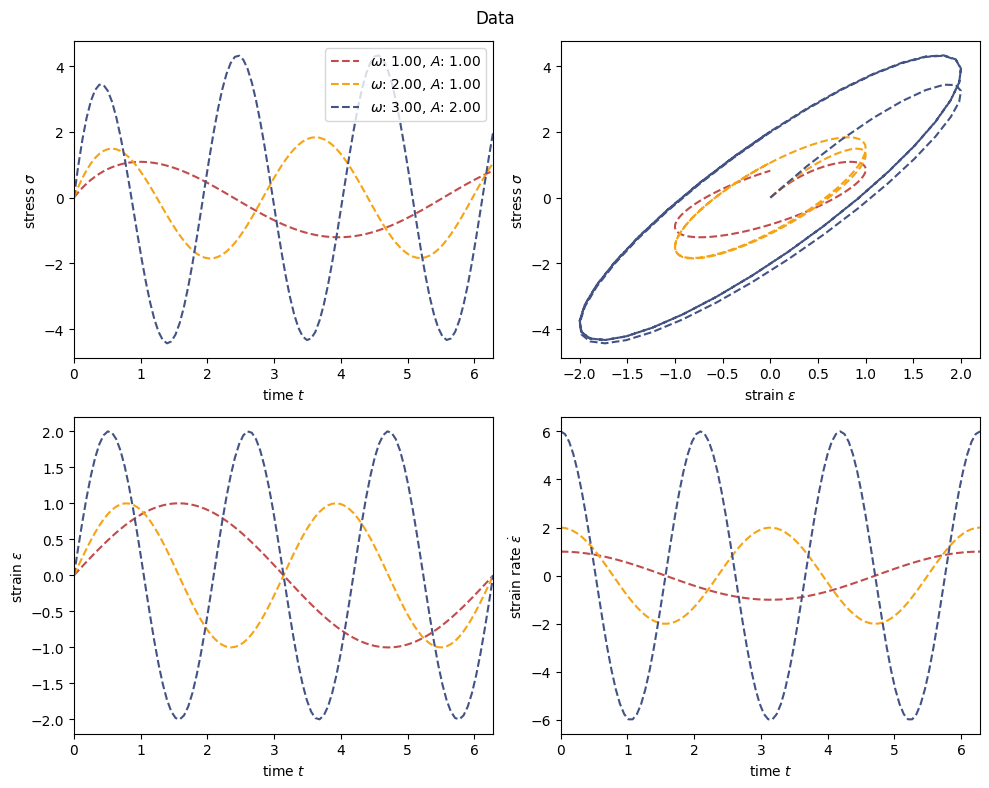

In [3]:
# All load cases
omegas_all = [1, 2, 3]
As_all = [1, 1, 2]

eps_all, eps_dot_all, sig_all, dts_all = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_all, As_all
)
tp.plot_data(eps_all, eps_dot_all, sig_all, omegas_all, As_all)

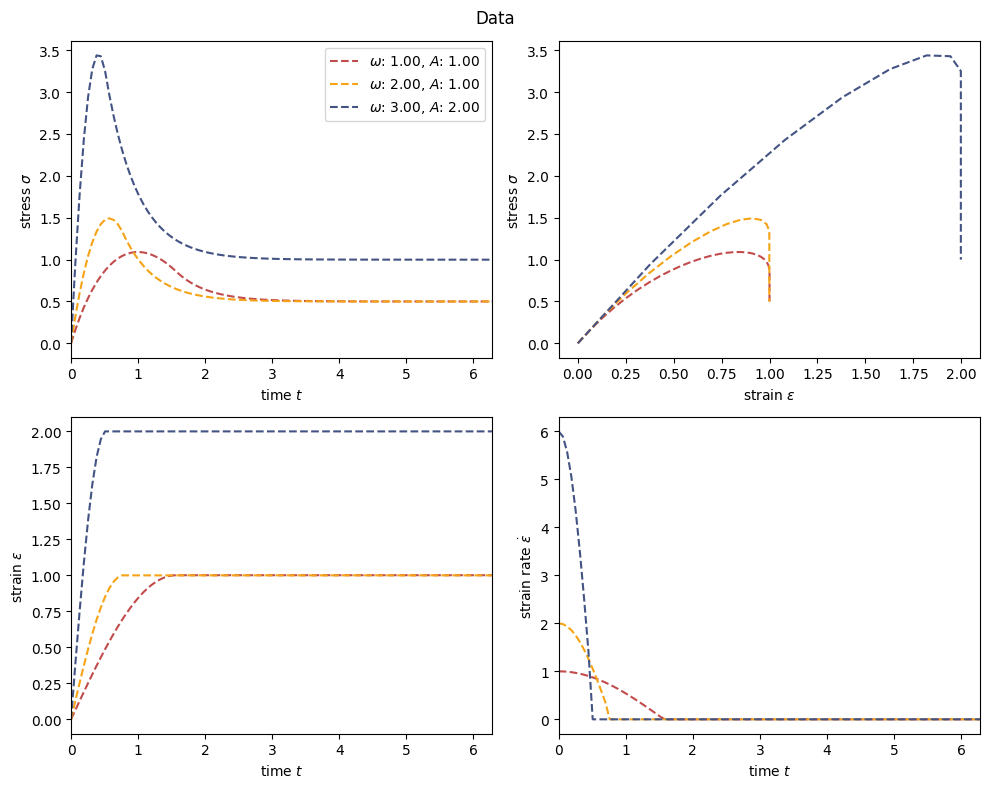

In [4]:
# Relaxation data
eps_relax, eps_dot_relax, sig_relax, dts_relax = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_all, As_all
)
tp.plot_data(eps_relax, eps_dot_relax, sig_relax, omegas_all, As_all)

## Modell 1: Simple RNN

Naiver RNN ohne physikalische Informationen. Das Netzwerk lernt direkt die Abbildung
$(\gamma_\text{old}, \varepsilon, \Delta t) \to (\gamma_\text{new}, \sigma)$.

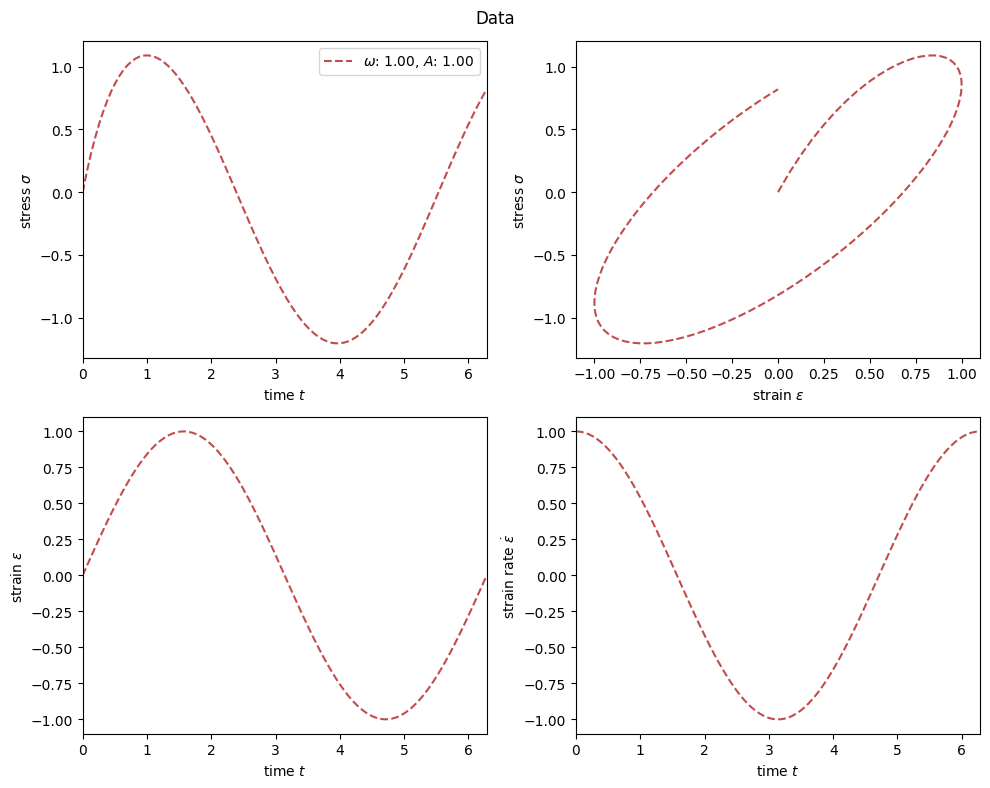

In [5]:
# Calibration data: (A=1, omega=1)
omegas_cal = [1.0]
As_cal = [1.0]

eps_cal, eps_dot_cal, sig_cal, dts_cal = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_cal, As_cal
)
tp.plot_data(eps_cal, eps_dot_cal, sig_cal, omegas_cal, As_cal)

In [ ]:
# Build and train Simple RNN
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_rnn = tm.build(key=keys[0])

model_rnn, history_rnn = klax.fit(
    model_rnn,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=1000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_rnn.plot()

In [7]:
model_rnn_ = klax.finalize(model_rnn)

### Interpolation: Test auf Trainingsdaten

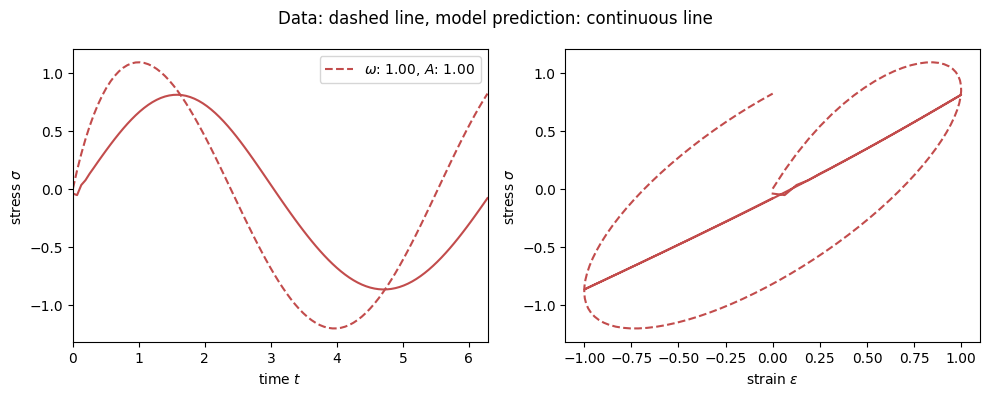

In [8]:
sig_pred = jax.vmap(model_rnn_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_pred, omegas_cal, As_cal)

### Extrapolation: Test auf neue Lastfälle

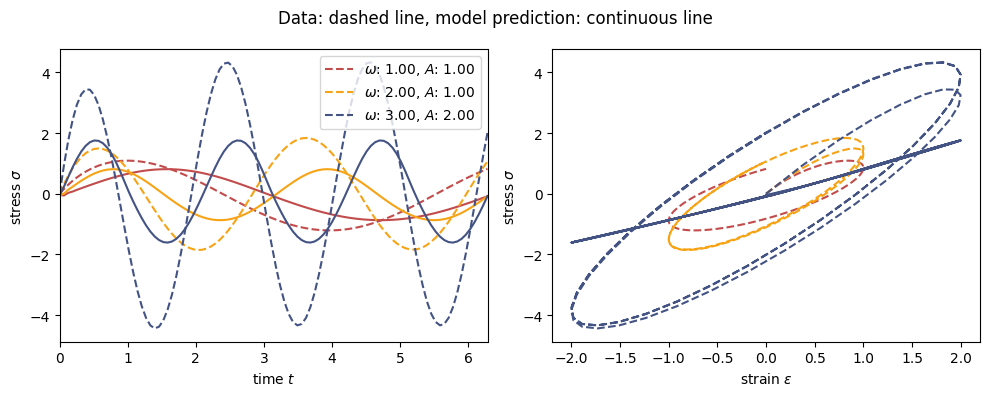

In [9]:
# Test on all harmonic load cases
omegas_test = [1, 2, 3]
As_test = [1, 1, 2]

eps_test, eps_dot_test, sig_test, dts_test = td.generate_data_harmonic(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_test = jax.vmap(model_rnn_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_pred_test, omegas_test, As_test)

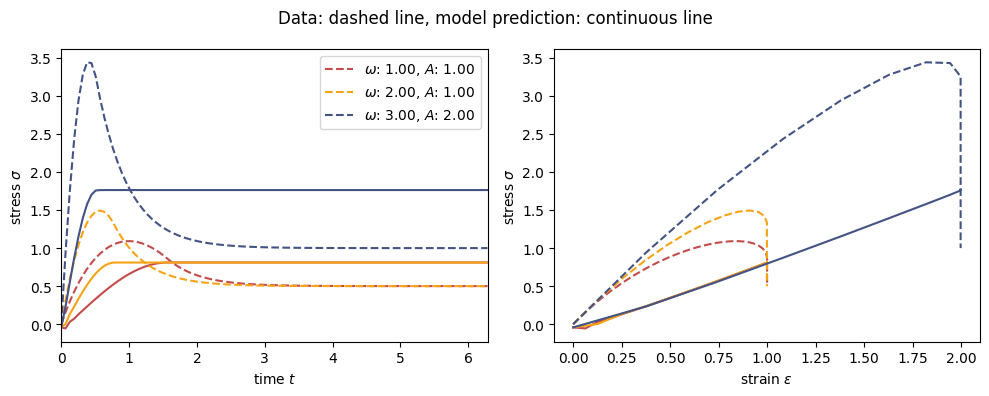

In [10]:
# Test on relaxation
eps_relax_test, eps_dot_relax_test, sig_relax_test, dts_relax_test = td.generate_data_relaxation(
    E_infty, E, eta, n, omegas_test, As_test
)
sig_pred_relax = jax.vmap(model_rnn_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_pred_relax, omegas_test, As_test)

---
## Modell 2: Maxwell-Modell

### 2a) Analytisches Maxwell-Modell (nicht trainierbar)

Feste Gleichungen:
- $e(\varepsilon, \gamma) = \frac{1}{2} E^\infty \varepsilon^2 + \frac{1}{2} E (\varepsilon - \gamma)^2$
- $\sigma = E^\infty \varepsilon + E(\varepsilon - \gamma)$
- $\dot{\gamma} = \frac{E}{\eta}(\varepsilon - \gamma)$

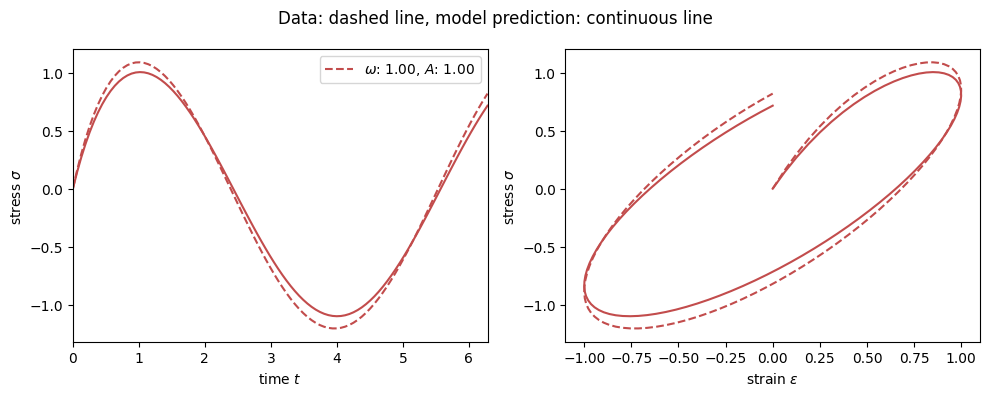

In [11]:
# Analytical Maxwell model (no training needed)
model_maxwell = tm.build_maxwell(E_infty=E_infty, E_val=E, eta=eta)

# Test on calibration data
sig_maxwell_cal = jax.vmap(model_maxwell)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_maxwell_cal, omegas_cal, As_cal)

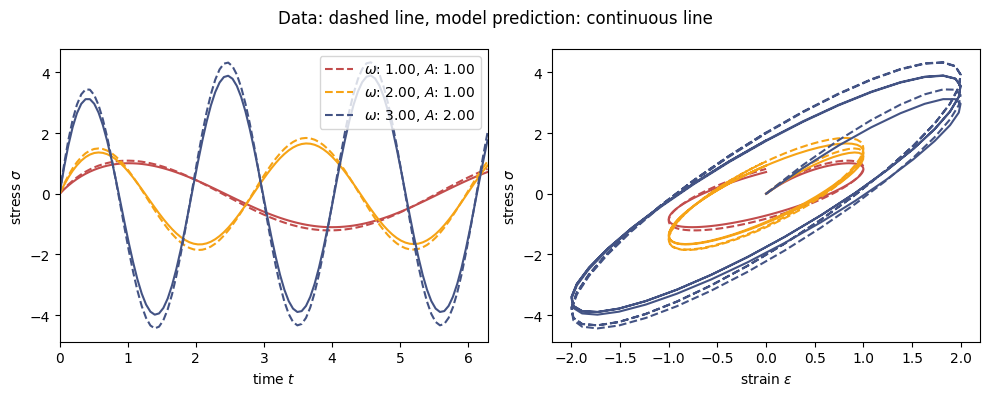

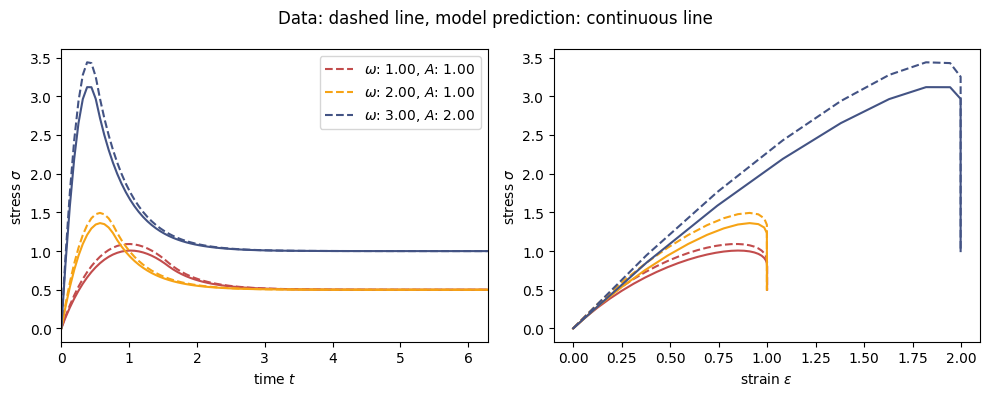

In [12]:
# Test on all load cases + relaxation
sig_maxwell_all = jax.vmap(model_maxwell)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_maxwell_all, omegas_test, As_test)

sig_maxwell_relax = jax.vmap(model_maxwell)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_maxwell_relax, omegas_test, As_test)

### 2b) Maxwell-Modell mit NN Evolutionsgleichung

In [ ]:
# Build and train Maxwell model with NN evolution equation
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_mnn = tm.build_maxwell_nn(key=keys[0], E_infty=E_infty, E_val=E)

model_mnn, history_mnn = klax.fit(
    model_mnn,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=1000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_mnn.plot()

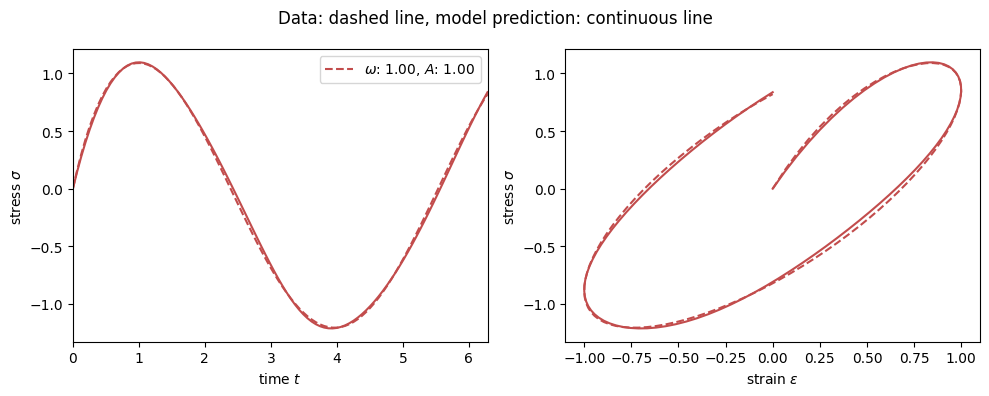

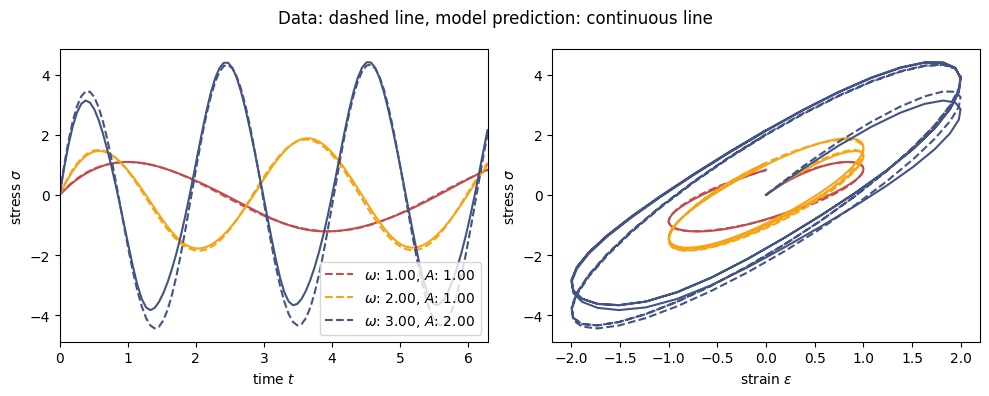

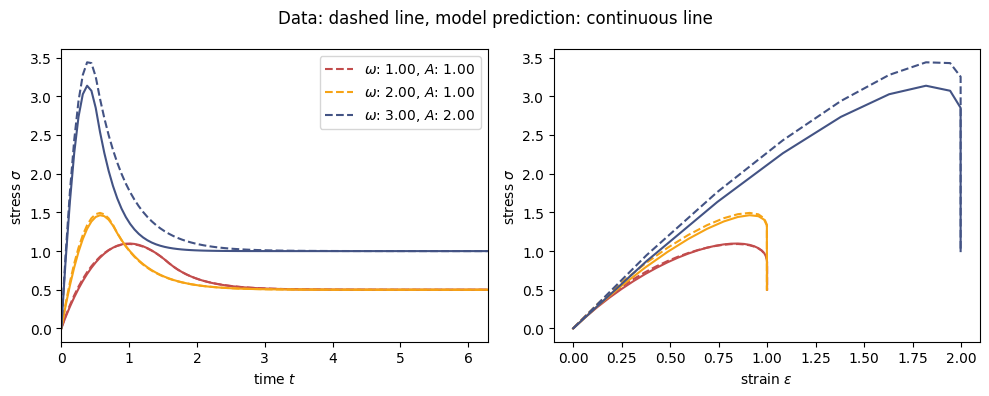

In [14]:
model_mnn_ = klax.finalize(model_mnn)

# Interpolation
sig_mnn_cal = jax.vmap(model_mnn_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_mnn_cal, omegas_cal, As_cal)

# Extrapolation
sig_mnn_test = jax.vmap(model_mnn_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_mnn_test, omegas_test, As_test)

# Relaxation
sig_mnn_relax = jax.vmap(model_mnn_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_mnn_relax, omegas_test, As_test)

---
## Modell 3: GSM-Modell (Generalized Standard Materials)

- $e = e(\varepsilon, \gamma)$ durch FFNN
- $\sigma = \frac{\partial e}{\partial \varepsilon}$
- $\dot{\gamma} = -g \cdot \frac{\partial e}{\partial \gamma}$, mit $g = \eta^{-1} = 1$

In [ ]:
# Build and train GSM model
key = jrandom.PRNGKey(time.time_ns())
keys = jrandom.split(key, 2)

model_gsm = tm.build_gsm(key=keys[0], g=1.0 / eta)

model_gsm, history_gsm = klax.fit(
    model_gsm,
    ((eps_cal, dts_cal), sig_cal),
    batch_axis=0,
    steps=1000,
    history=klax.HistoryCallback(log_every=100),
    key=keys[1],
)

history_gsm.plot()

In [ ]:
model_gsm_ = klax.finalize(model_gsm)

# Interpolation
sig_gsm_cal = jax.vmap(model_gsm_)((eps_cal, dts_cal))
tp.plot_model_pred(eps_cal, sig_cal, sig_gsm_cal, omegas_cal, As_cal)

# Extrapolation
sig_gsm_test = jax.vmap(model_gsm_)((eps_test, dts_test))
tp.plot_model_pred(eps_test, sig_test, sig_gsm_test, omegas_test, As_test)

# Relaxation
sig_gsm_relax = jax.vmap(model_gsm_)((eps_relax_test, dts_relax_test))
tp.plot_model_pred(eps_relax_test, sig_relax_test, sig_gsm_relax, omegas_test, As_test)